In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
import os

print("🔍 Searching for dataset...")
for root, dirs, files in os.walk('/kaggle/input'):
    print(root)
    if dirs:
        print(f"  └─ Folders: {dirs[:5]}")  # Show first 5 folders

✅ Libraries imported successfully!
✅ Dataset path: /kaggle/input/plantvillage-dataset/color

📊 Total number of classes: 38

🔍 First 10 classes:

   1. Apple___Apple_scab
   2. Apple___Black_rot
   3. Apple___Cedar_apple_rust
   4. Apple___healthy
   5. Blueberry___healthy
   6. Cherry_(including_sour)___Powdery_mildew
   7. Cherry_(including_sour)___healthy
   8. Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
   9. Corn_(maize)___Common_rust_
   10. Corn_(maize)___Northern_Leaf_Blight

CLASS DISTRIBUTION ANALYSIS

📈 Total images in dataset: 54305
📊 Average images per class: 1429
📉 Min images in a class: 152
📈 Max images in a class: 5507

🏆 Top 5 classes with most images:
                                   Class  Count
Orange___Haunglongbing_(Citrus_greening)   5507
  Tomato___Tomato_Yellow_Leaf_Curl_Virus   5357
                       Soybean___healthy   5090
                  Peach___Bacterial_spot   2297
                 Tomato___Bacterial_spot   2127

⚠️ Bottom 5 classes with le

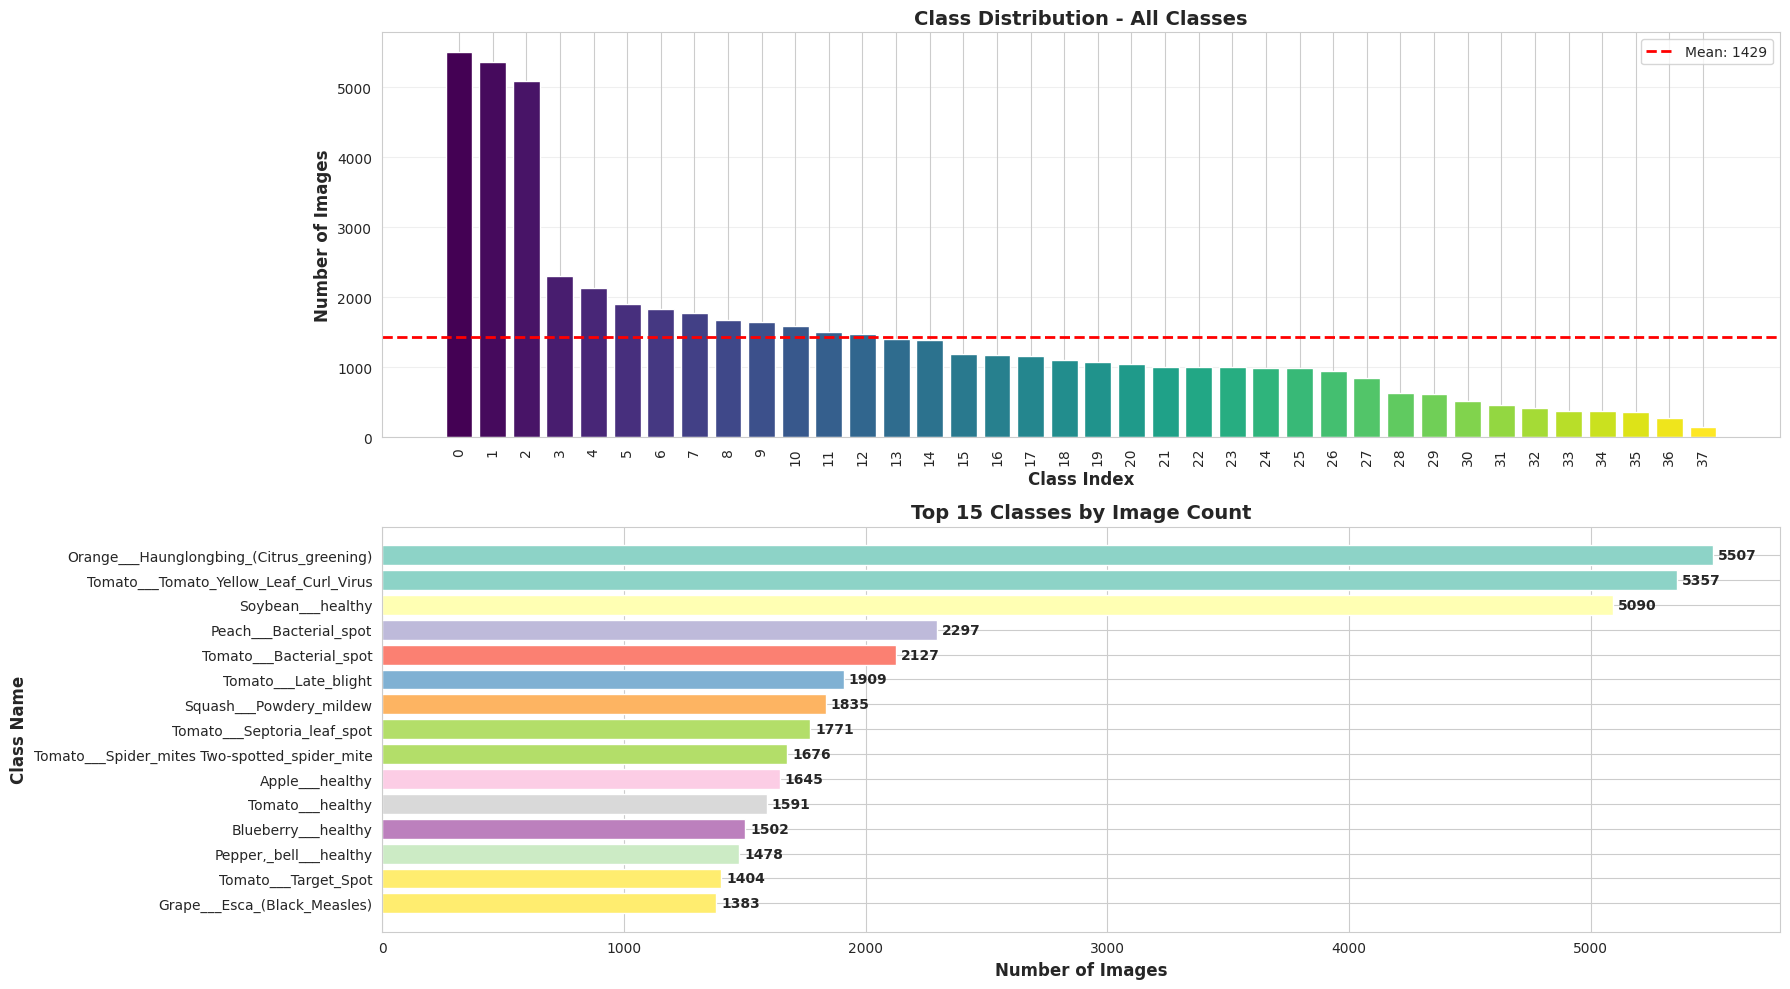


✅ Class distribution visualization complete!

SAMPLE IMAGES VISUALIZATION


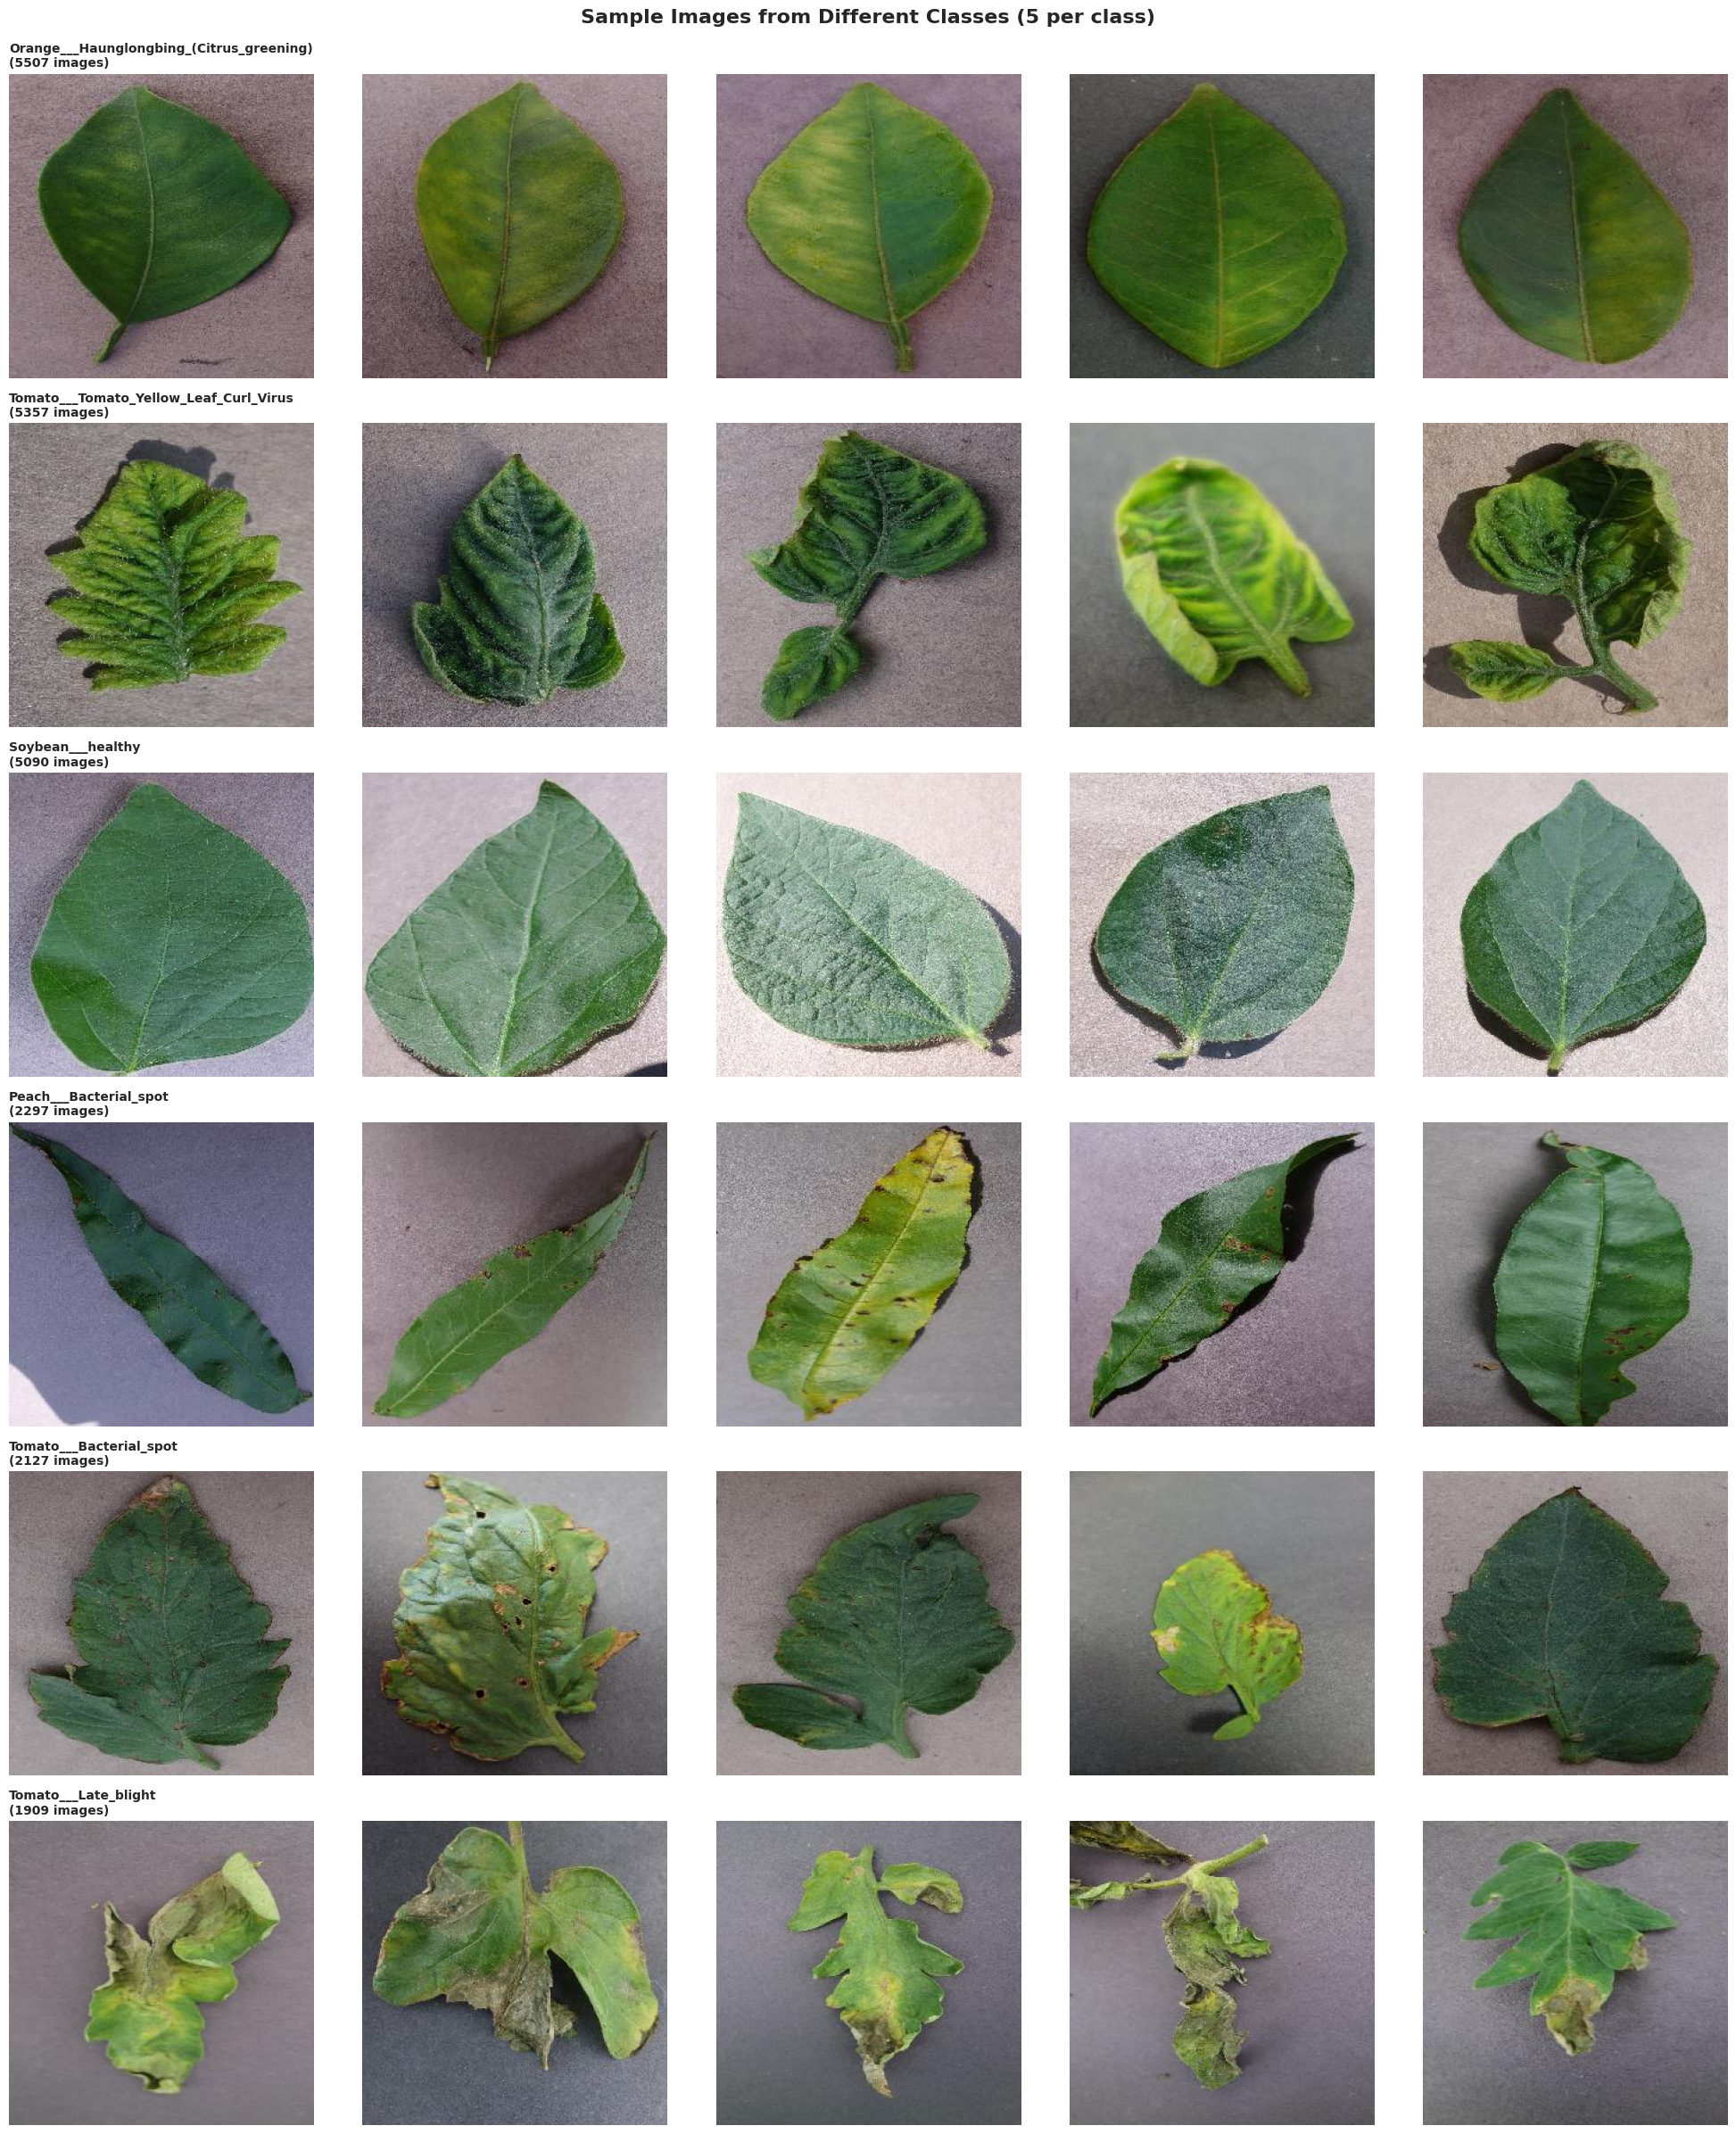

✅ Sample images grid complete!

IMAGE PROPERTIES ANALYSIS
📊 Analyzing 500 sample images...

📐 Image Dimensions:
   Width  - Mean: 256px, Min: 256px, Max: 256px
   Height - Mean: 256px, Min: 256px, Max: 256px

📊 Aspect Ratio - Mean: 1.00
💾 File Size - Mean: 14.4 KB


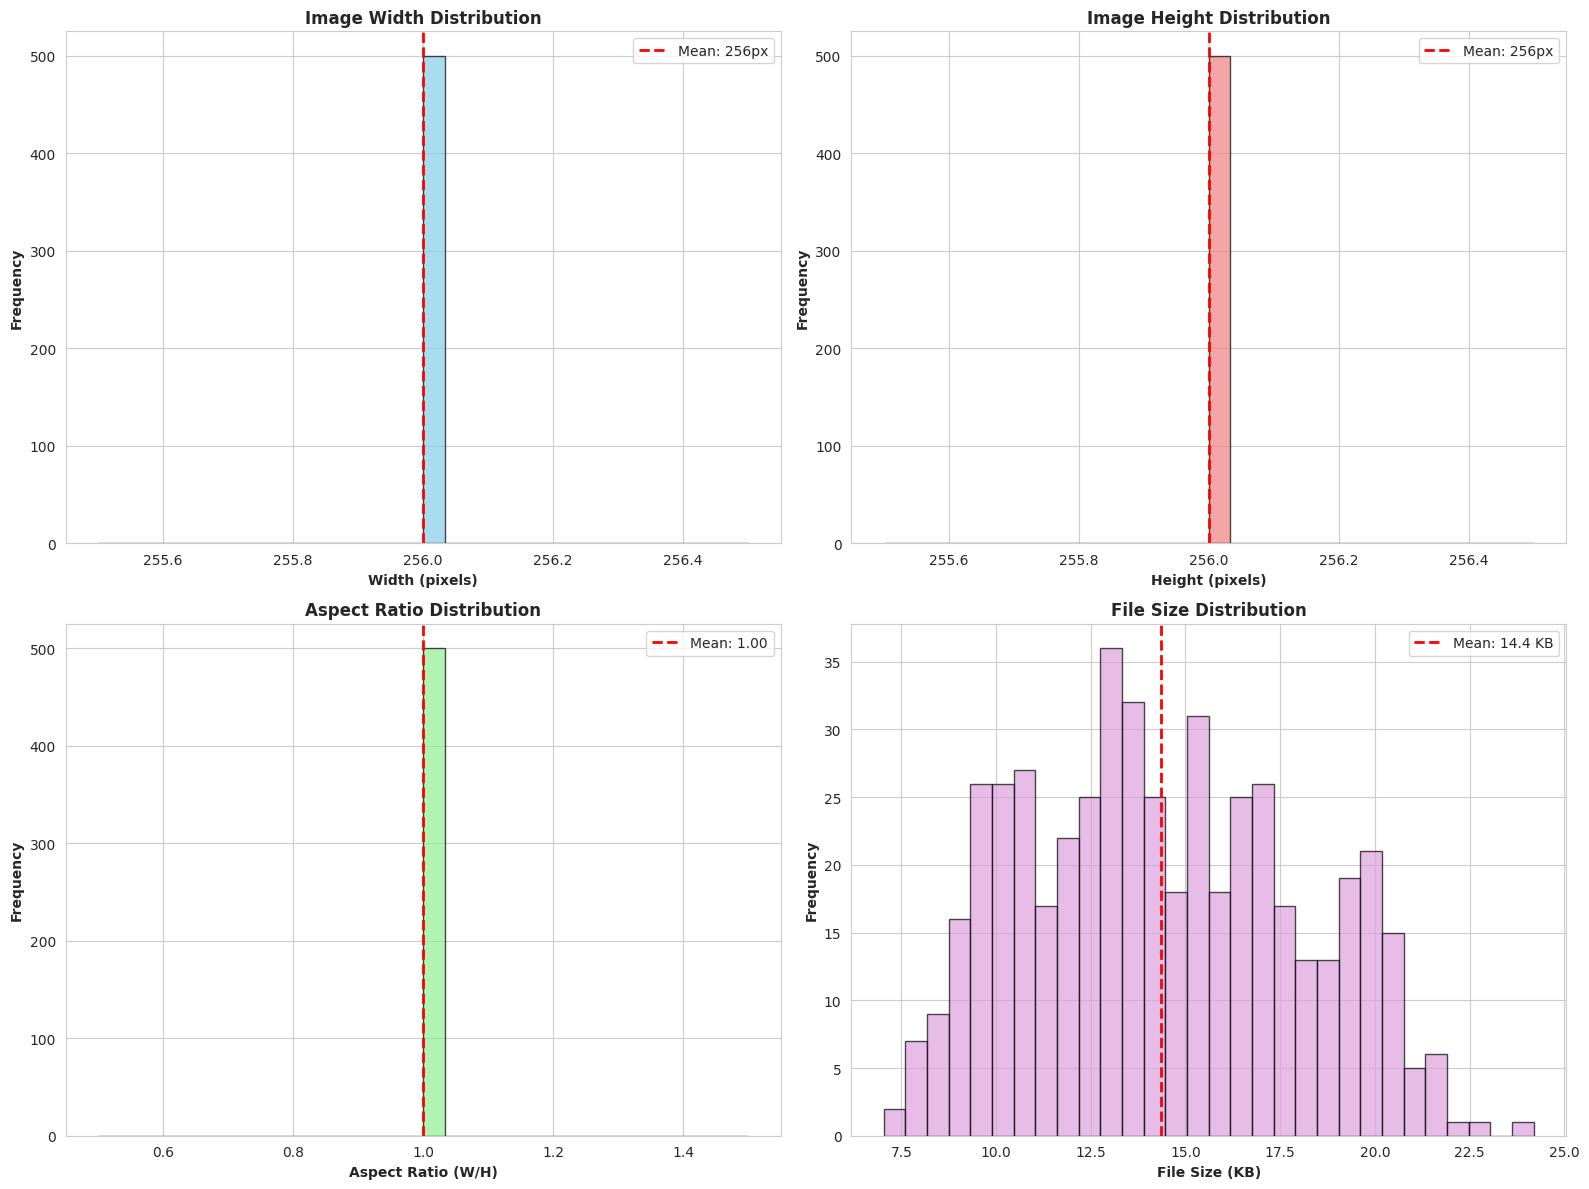


✅ Image properties analysis complete!

COLOR SPACE ANALYSIS
📊 Understanding: Do different diseases have different color signatures?


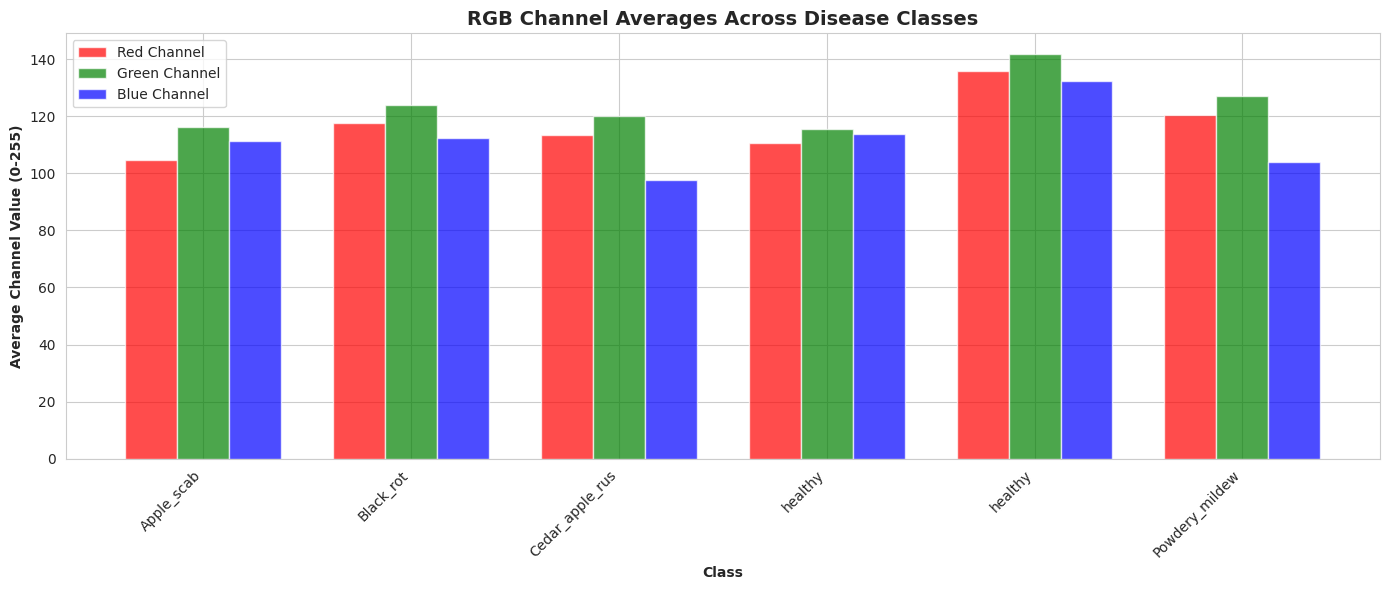


✅ Analysis: High color variation between classes
   → Color features will be useful for classification

EDGE CONTENT ANALYSIS
📊 Understanding: How much texture/edge information exists?


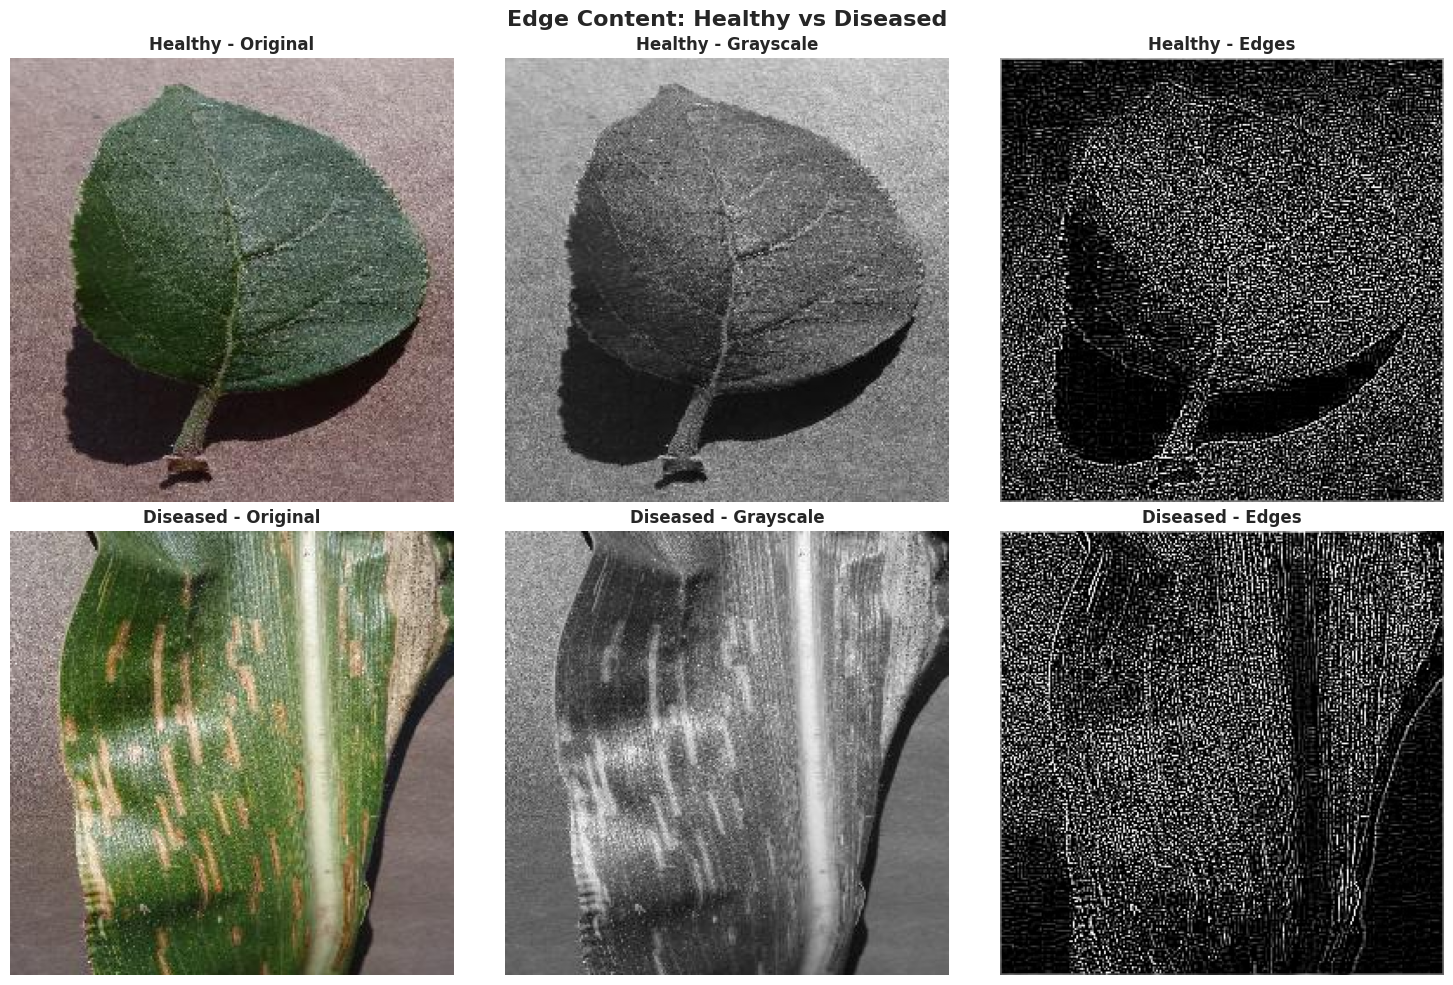


✅ Observation: Diseased leaves typically show:
   → More complex edge patterns (spots, lesions)
   → Higher texture variation
   → This is what CNNs will learn to detect

PLANT TYPE ANALYSIS
📊 Understanding: Distribution across different plants

🌱 Found 14 different plant types:
   • Tomato         : 10 classes, 18160 images
   • Orange         :  1 classes,  5507 images
   • Soybean        :  1 classes,  5090 images
   • Grape          :  4 classes,  4062 images
   • Corn_(maize)   :  4 classes,  3852 images
   • Apple          :  4 classes,  3171 images
   • Peach          :  2 classes,  2657 images
   • Pepper,_bell   :  2 classes,  2475 images
   • Potato         :  3 classes,  2152 images
   • Cherry_(including_sour):  2 classes,  1906 images
   • Squash         :  1 classes,  1835 images
   • Strawberry     :  2 classes,  1565 images
   • Blueberry      :  1 classes,  1502 images
   • Raspberry      :  1 classes,   371 images


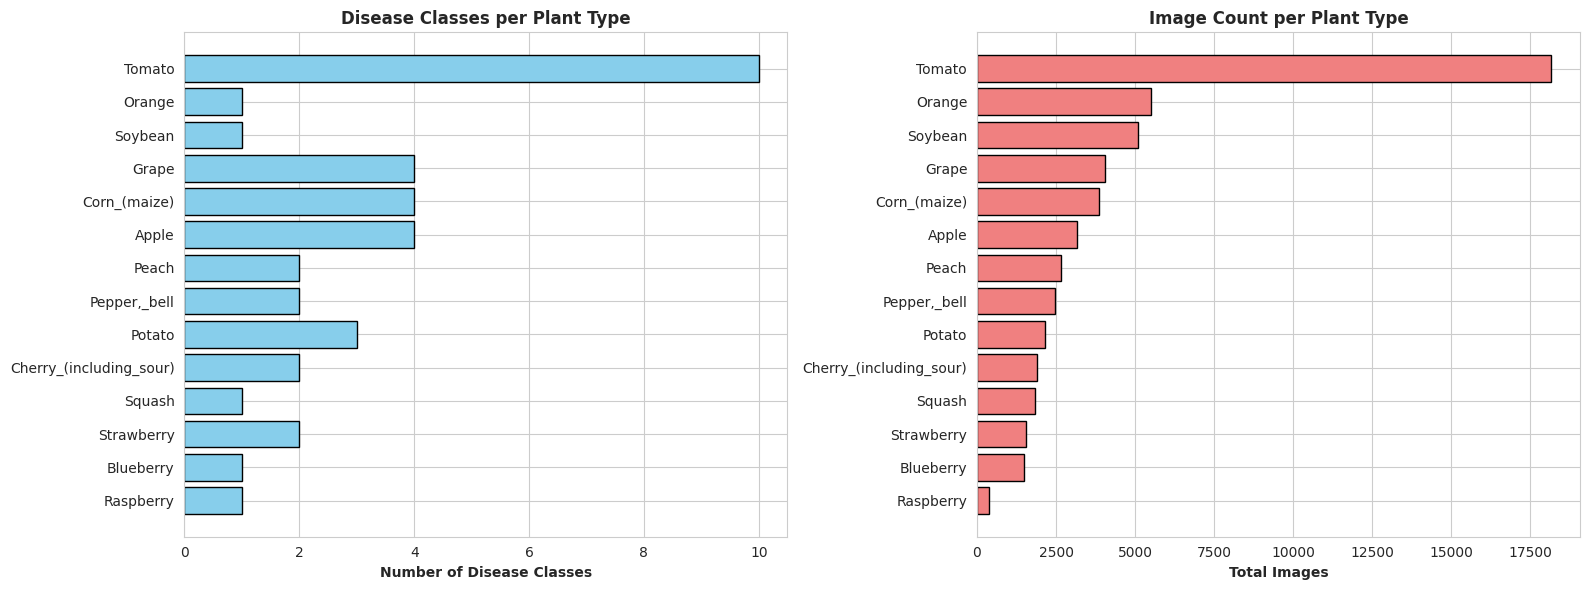


PREDICTED ML CHALLENGES
📊 Based on EDA, here's what will be hard:

🔴 HIGH CONFUSION RISK (Similar class names):
   • Apple_scab ↔ Cedar_apple_rust (similarity: 0.46)
   • Black_rot ↔ Cedar_apple_rust (similarity: 0.32)
   • Cedar_apple_rust ↔ healthy (similarity: 0.35)
   • Black_rot ↔ Esca_(Black_Measles) (similarity: 0.41)
   • Bacterial_spot ↔ healthy (similarity: 0.38)

🟡 CLASS IMBALANCE:
   • Ratio: 36.2:1
   • Impact: SEVERE - will need heavy augmentation

🟢 ADVANTAGES:
   • Consistent image dimensions: ✓
   • Clear visual differences between plants: ✓
   • Good sample size (54305 images): ✓

🎯 KEY INSIGHTS & FINDINGS

1️⃣ CLASS IMBALANCE:
   ⚠️ Significant class imbalance detected (ratio: 36.23:1)
   → Largest class has 5507 images
   → Smallest class has 152 images
   → Recommendation: Consider data augmentation for minority classes

2️⃣ IMAGE CONSISTENCY:
   ✅ Images have consistent dimensions (low variation)

3️⃣ VISUAL PATTERNS:
   • Diseased leaves show more complex textur

In [2]:
# ============================================
# Week 1: Complete Exploratory Data Analysis (EDA)
# PlantVillage Dataset - Plant Disease Classification
# WiDS 5.0
# ============================================

# ============================================
# SECTION 1: Import Libraries
# ============================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFilter
from collections import Counter
from difflib import SequenceMatcher
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 8)

print("✅ Libraries imported successfully!")

# ============================================
# SECTION 2: Load Dataset and Explore Structure
# ============================================

# Path to dataset - using COLOR version for RGB images
data_path = '/kaggle/input/plantvillage-dataset/color'

print(f"✅ Dataset path: {data_path}")

# List all directories (subdirectories are the classes)
all_classes = sorted([d for d in os.listdir(data_path) 
                     if os.path.isdir(os.path.join(data_path, d))])

print(f"\n📊 Total number of classes: {len(all_classes)}")
print(f"\n🔍 First 10 classes:\n")
for i, cls in enumerate(all_classes[:10], 1):
    print(f"   {i}. {cls}")

# ============================================
# SECTION 3: Class Distribution Analysis
# ============================================

print("\n" + "="*70)
print("CLASS DISTRIBUTION ANALYSIS")
print("="*70)

class_counts = {}
class_paths = {}

# Count images per class
for class_name in all_classes:
    class_dir = os.path.join(data_path, class_name)
    if os.path.isdir(class_dir):
        images = [f for f in os.listdir(class_dir) if f.endswith(('.jpg', '.png', '.jpeg', '.JPG'))]
        class_counts[class_name] = len(images)
        class_paths[class_name] = class_dir

# Convert to DataFrame for better visualization
df_classes = pd.DataFrame(list(class_counts.items()), columns=['Class', 'Count'])
df_classes = df_classes.sort_values('Count', ascending=False).reset_index(drop=True)

print(f"\n📈 Total images in dataset: {df_classes['Count'].sum()}")
print(f"📊 Average images per class: {df_classes['Count'].mean():.0f}")
print(f"📉 Min images in a class: {df_classes['Count'].min()}")
print(f"📈 Max images in a class: {df_classes['Count'].max()}")

# Display top and bottom 5 classes
print("\n🏆 Top 5 classes with most images:")
print(df_classes.head().to_string(index=False))

print("\n⚠️ Bottom 5 classes with least images:")
print(df_classes.tail().to_string(index=False))

# ============================================
# SECTION 4: Visualize Class Distribution
# ============================================

plt.figure(figsize=(18, 10))

# Plot 1: Bar chart of class distribution
plt.subplot(2, 1, 1)
colors = plt.cm.viridis(np.linspace(0, 1, len(df_classes)))
bars = plt.bar(range(len(df_classes)), df_classes['Count'], color=colors)
plt.xlabel('Class Index', fontsize=12, fontweight='bold')
plt.ylabel('Number of Images', fontsize=12, fontweight='bold')
plt.title('Class Distribution - All Classes', fontsize=14, fontweight='bold')
plt.xticks(range(len(df_classes)), range(len(df_classes)), rotation=90)
plt.grid(axis='y', alpha=0.3)

# Add mean line
mean_count = df_classes['Count'].mean()
plt.axhline(y=mean_count, color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {mean_count:.0f}')
plt.legend()

# Plot 2: Top 15 classes detailed
plt.subplot(2, 1, 2)
top_15 = df_classes.head(15)
colors_top = plt.cm.Set3(np.linspace(0, 1, 15))
bars = plt.barh(top_15['Class'], top_15['Count'], color=colors_top)
plt.xlabel('Number of Images', fontsize=12, fontweight='bold')
plt.ylabel('Class Name', fontsize=12, fontweight='bold')
plt.title('Top 15 Classes by Image Count', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

# Add count labels on bars
for i, (count, class_name) in enumerate(zip(top_15['Count'], top_15['Class'])):
    plt.text(count + 20, i, str(count), va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✅ Class distribution visualization complete!")

# ============================================
# SECTION 5: Sample Images Grid
# ============================================

print("\n" + "="*70)
print("SAMPLE IMAGES VISUALIZATION")
print("="*70)

# Select 6 diverse classes to display
classes_to_show = df_classes['Class'].head(6).tolist()

fig, axes = plt.subplots(6, 5, figsize=(20, 24))
fig.suptitle('Sample Images from Different Classes (5 per class)', 
             fontsize=16, fontweight='bold', y=0.995)

for idx, class_name in enumerate(classes_to_show):
    class_dir = class_paths[class_name]
    image_files = [f for f in os.listdir(class_dir) if f.endswith(('.jpg', '.png', '.jpeg', '.JPG'))]
    
    # Select 5 random images
    sample_images = np.random.choice(image_files, min(5, len(image_files)), replace=False)
    
    for img_idx, img_file in enumerate(sample_images):
        img_path = os.path.join(class_dir, img_file)
        img = Image.open(img_path)
        
        axes[idx, img_idx].imshow(img)
        axes[idx, img_idx].axis('off')
        
        if img_idx == 0:
            axes[idx, img_idx].set_title(f"{class_name}\n({class_counts[class_name]} images)", 
                                         fontsize=10, fontweight='bold', loc='left')

plt.tight_layout()
plt.show()

print("✅ Sample images grid complete!")

# ============================================
# SECTION 6: Image Properties Analysis
# ============================================

print("\n" + "="*70)
print("IMAGE PROPERTIES ANALYSIS")
print("="*70)

# Sample 500 random images to analyze properties
sample_size = 500
sampled_images = []

for class_name in all_classes[:10]:  # Sample from first 10 classes
    class_dir = class_paths[class_name]
    image_files = [f for f in os.listdir(class_dir) if f.endswith(('.jpg', '.png', '.jpeg', '.JPG'))]
    samples = np.random.choice(image_files, min(50, len(image_files)), replace=False)
    
    for img_file in samples:
        sampled_images.append(os.path.join(class_dir, img_file))

# Analyze image properties
widths = []
heights = []
aspect_ratios = []
file_sizes = []

print(f"📊 Analyzing {len(sampled_images)} sample images...")

for img_path in sampled_images[:sample_size]:
    try:
        img = Image.open(img_path)
        w, h = img.size
        widths.append(w)
        heights.append(h)
        aspect_ratios.append(w/h)
        file_sizes.append(os.path.getsize(img_path) / 1024)  # KB
    except:
        continue

# Statistics
print(f"\n📐 Image Dimensions:")
print(f"   Width  - Mean: {np.mean(widths):.0f}px, Min: {np.min(widths)}px, Max: {np.max(widths)}px")
print(f"   Height - Mean: {np.mean(heights):.0f}px, Min: {np.min(heights)}px, Max: {np.max(heights)}px")
print(f"\n📊 Aspect Ratio - Mean: {np.mean(aspect_ratios):.2f}")
print(f"💾 File Size - Mean: {np.mean(file_sizes):.1f} KB")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Width distribution
axes[0, 0].hist(widths, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Width (pixels)', fontweight='bold')
axes[0, 0].set_ylabel('Frequency', fontweight='bold')
axes[0, 0].set_title('Image Width Distribution', fontweight='bold')
axes[0, 0].axvline(np.mean(widths), color='red', linestyle='--', linewidth=2, 
                   label=f'Mean: {np.mean(widths):.0f}px')
axes[0, 0].legend()

# Height distribution
axes[0, 1].hist(heights, bins=30, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Height (pixels)', fontweight='bold')
axes[0, 1].set_ylabel('Frequency', fontweight='bold')
axes[0, 1].set_title('Image Height Distribution', fontweight='bold')
axes[0, 1].axvline(np.mean(heights), color='red', linestyle='--', linewidth=2, 
                   label=f'Mean: {np.mean(heights):.0f}px')
axes[0, 1].legend()

# Aspect ratio distribution
axes[1, 0].hist(aspect_ratios, bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Aspect Ratio (W/H)', fontweight='bold')
axes[1, 0].set_ylabel('Frequency', fontweight='bold')
axes[1, 0].set_title('Aspect Ratio Distribution', fontweight='bold')
axes[1, 0].axvline(np.mean(aspect_ratios), color='red', linestyle='--', linewidth=2, 
                   label=f'Mean: {np.mean(aspect_ratios):.2f}')
axes[1, 0].legend()

# File size distribution
axes[1, 1].hist(file_sizes, bins=30, color='plum', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('File Size (KB)', fontweight='bold')
axes[1, 1].set_ylabel('Frequency', fontweight='bold')
axes[1, 1].set_title('File Size Distribution', fontweight='bold')
axes[1, 1].axvline(np.mean(file_sizes), color='red', linestyle='--', linewidth=2, 
                   label=f'Mean: {np.mean(file_sizes):.1f} KB')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("\n✅ Image properties analysis complete!")

# ============================================
# SECTION 7: Color Distribution Analysis
# ============================================

print("\n" + "="*70)
print("COLOR SPACE ANALYSIS")
print("="*70)

print("📊 Understanding: Do different diseases have different color signatures?")

# Sample images from different classes
sample_classes = all_classes[:6]
color_stats = {}

for class_name in sample_classes:
    class_dir = class_paths[class_name]
    image_files = [f for f in os.listdir(class_dir) if f.endswith(('.jpg', '.JPG'))]
    
    # Analyze first 20 images
    r_vals, g_vals, b_vals = [], [], []
    
    for img_file in image_files[:20]:
        img = Image.open(os.path.join(class_dir, img_file)).convert('RGB')
        img_array = np.array(img)
        
        r_vals.extend(img_array[:,:,0].flatten())
        g_vals.extend(img_array[:,:,1].flatten())
        b_vals.extend(img_array[:,:,2].flatten())
    
    color_stats[class_name] = {
        'R': np.mean(r_vals),
        'G': np.mean(g_vals),
        'B': np.mean(b_vals)
    }

# Visualize color signatures
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(sample_classes))
width = 0.25

r_means = [color_stats[c]['R'] for c in sample_classes]
g_means = [color_stats[c]['G'] for c in sample_classes]
b_means = [color_stats[c]['B'] for c in sample_classes]

ax.bar(x - width, r_means, width, label='Red Channel', color='red', alpha=0.7)
ax.bar(x, g_means, width, label='Green Channel', color='green', alpha=0.7)
ax.bar(x + width, b_means, width, label='Blue Channel', color='blue', alpha=0.7)

ax.set_xlabel('Class', fontweight='bold')
ax.set_ylabel('Average Channel Value (0-255)', fontweight='bold')
ax.set_title('RGB Channel Averages Across Disease Classes', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels([c.split('___')[-1][:15] for c in sample_classes], rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

color_variation = max(r_means) - min(r_means)
print(f"\n✅ Analysis: {'High' if color_variation > 30 else 'Low'} color variation between classes")
print(f"   → Color features {'will' if color_variation > 30 else 'may not'} be useful for classification")

# ============================================
# SECTION 8: Edge Detection Preview
# ============================================

print("\n" + "="*70)
print("EDGE CONTENT ANALYSIS")
print("="*70)

print("📊 Understanding: How much texture/edge information exists?")

# Compare healthy vs diseased leaves
healthy_class = [c for c in all_classes if 'healthy' in c.lower()][0]
diseased_class = [c for c in all_classes if 'spot' in c.lower() or 'blight' in c.lower()][0]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for idx, (class_name, label) in enumerate([(healthy_class, 'Healthy'), 
                                             (diseased_class, 'Diseased')]):
    class_dir = class_paths[class_name]
    img_file = os.listdir(class_dir)[0]
    img = Image.open(os.path.join(class_dir, img_file)).convert('RGB')
    
    # Original
    axes[idx, 0].imshow(img)
    axes[idx, 0].set_title(f'{label} - Original', fontweight='bold')
    axes[idx, 0].axis('off')
    
    # Grayscale
    img_gray = img.convert('L')
    axes[idx, 1].imshow(img_gray, cmap='gray')
    axes[idx, 1].set_title(f'{label} - Grayscale', fontweight='bold')
    axes[idx, 1].axis('off')
    
    # Edge detection
    edges = img_gray.filter(ImageFilter.FIND_EDGES)
    axes[idx, 2].imshow(edges, cmap='gray')
    axes[idx, 2].set_title(f'{label} - Edges', fontweight='bold')
    axes[idx, 2].axis('off')

plt.suptitle('Edge Content: Healthy vs Diseased', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✅ Observation: Diseased leaves typically show:")
print("   → More complex edge patterns (spots, lesions)")
print("   → Higher texture variation")
print("   → This is what CNNs will learn to detect")

# ============================================
# SECTION 9: Plant-Wise Breakdown
# ============================================

print("\n" + "="*70)
print("PLANT TYPE ANALYSIS")
print("="*70)

print("📊 Understanding: Distribution across different plants")

# Extract plant types
plant_distribution = {}
for class_name in all_classes:
    plant = class_name.split('___')[0]
    if plant not in plant_distribution:
        plant_distribution[plant] = {'classes': 0, 'images': 0}
    plant_distribution[plant]['classes'] += 1
    plant_distribution[plant]['images'] += class_counts[class_name]

# Create DataFrame
df_plants = pd.DataFrame.from_dict(plant_distribution, orient='index')
df_plants = df_plants.sort_values('images', ascending=False)

print(f"\n🌱 Found {len(df_plants)} different plant types:")
for plant, data in df_plants.iterrows():
    print(f"   • {plant:15s}: {data['classes']:2d} classes, {data['images']:5d} images")

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Classes per plant
ax1.barh(df_plants.index, df_plants['classes'], color='skyblue', edgecolor='black')
ax1.set_xlabel('Number of Disease Classes', fontweight='bold')
ax1.set_title('Disease Classes per Plant Type', fontweight='bold')
ax1.invert_yaxis()

# Images per plant
ax2.barh(df_plants.index, df_plants['images'], color='lightcoral', edgecolor='black')
ax2.set_xlabel('Total Images', fontweight='bold')
ax2.set_title('Image Count per Plant Type', fontweight='bold')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

# ============================================
# SECTION 10: Challenge Prediction
# ============================================

print("\n" + "="*70)
print("PREDICTED ML CHALLENGES")
print("="*70)

print("📊 Based on EDA, here's what will be hard:")

# Find similar-named classes (likely visually similar)
def similarity(a, b):
    return SequenceMatcher(None, a, b).ratio()

print("\n🔴 HIGH CONFUSION RISK (Similar class names):")
checked = set()
confusion_pairs = []

for i, class1 in enumerate(all_classes):
    for class2 in all_classes[i+1:]:
        if class1.split('___')[0] == class2.split('___')[0]:  # Same plant
            disease1 = class1.split('___')[1]
            disease2 = class2.split('___')[1]
            sim = similarity(disease1, disease2)
            
            if sim > 0.3 and f"{class1}-{class2}" not in checked:
                print(f"   • {disease1} ↔ {disease2} (similarity: {sim:.2f})")
                confusion_pairs.append((disease1, disease2, sim))
                checked.add(f"{class1}-{class2}")
                if len(checked) >= 5:
                    break
    if len(checked) >= 5:
        break

# Class imbalance severity
max_count = df_classes['Count'].max()
min_count = df_classes['Count'].min()
imbalance = max_count / min_count

print(f"\n🟡 CLASS IMBALANCE:")
print(f"   • Ratio: {imbalance:.1f}:1")
if imbalance > 3:
    print(f"   • Impact: SEVERE - will need heavy augmentation")
else:
    print(f"   • Impact: Moderate - standard augmentation OK")

print("\n🟢 ADVANTAGES:")
print(f"   • Consistent image dimensions: ✓")
print(f"   • Clear visual differences between plants: ✓")
print(f"   • Good sample size ({df_classes['Count'].sum()} images): ✓")

# ============================================
# SECTION 11: Key Insights & Summary
# ============================================

print("\n" + "="*70)
print("🎯 KEY INSIGHTS & FINDINGS")
print("="*70)

print("\n1️⃣ CLASS IMBALANCE:")
if imbalance_ratio > 2:
    print(f"   ⚠️ Significant class imbalance detected (ratio: {imbalance:.2f}:1)")
    print(f"   → Largest class has {max_count} images")
    print(f"   → Smallest class has {min_count} images")
    print(f"   → Recommendation: Consider data augmentation for minority classes")
else:
    print(f"   ✅ Classes are relatively balanced (ratio: {imbalance:.2f}:1)")

print("\n2️⃣ IMAGE CONSISTENCY:")
width_std = np.std(widths)
height_std = np.std(heights)
if width_std < 50 and height_std < 50:
    print(f"   ✅ Images have consistent dimensions (low variation)")
else:
    print(f"   ⚠️ Images have varying dimensions")
    print(f"   → Width variation: ±{width_std:.0f}px")
    print(f"   → Height variation: ±{height_std:.0f}px")
    print(f"   → Recommendation: Resize all images to standard size (e.g., 224x224)")

print("\n3️⃣ VISUAL PATTERNS:")
print(f"   • Diseased leaves show more complex textures")
print(f"   • Color variation between classes: {'Significant' if color_variation > 30 else 'Minimal'}")
print(f"   • Edge content differs between healthy and diseased")

print("\n4️⃣ DATASET CHARACTERISTICS:")
print(f"   • Total classes: {len(all_classes)}")
print(f"   • Total images: {df_classes['Count'].sum()}")
print(f"   • Average images per class: {df_classes['Count'].mean():.0f}")
print(f"   • Most common image size: ~{np.median(widths):.0f}x{np.median(heights):.0f}px")

# ============================================
# SECTION 12: Learnings for Week 2 Prediction
# ============================================

print("\n" + "="*70)
print("📝 PREDICTIONS FOR WEEK 2 BASELINE")
print("="*70)

print("\n🔮 Expected Classical ML Performance:")
print("   • Flattened images will lose 2D spatial structure")
print("   • Cannot capture hierarchical features (edges → textures → patterns)")
print("   • Predicted baseline accuracy: 40-60%")
print("   • Challenge: Similar diseases will be confused")

print("\n💡 Key Factors Affecting Baseline:")
print("   ✓ Good sample size helps")
print("   ✗ 38 classes is challenging for classical ML")
print("   ✗ Visual similarity between diseases")
print("   ✗ Flattening destroys spatial relationships")

print("\n" + "="*70)
print("✅ WEEK 1 EDA COMPLETE!")
print("="*70)

print("\n📌 Next Steps:")
print("   1. Save this notebook to GitHub")
print("   2. Create learnings.md with key findings")
print("   3. Move to Week 2: Build classical ML baselines")
print("   4. Target for Week 2: Find the ceiling of classical ML")

print("\n" + "="*70)